In [ ]:
# 0. Setup

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Make plots a bit cleaner
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

In [ ]:
# 1. Load data

file_path = "cleaned_student_exam_wide_format - student_attributes_final_version_for_capstone.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (552, 46)


,Student ID,Gender,Type of Examinee,Pre-assessment 2025,Anatomy,Physiology,Parasitology,Pharmacology,Pathology,Zootechnics,...,avg_best_score,max_best_score,avg_first_score,avg_last_score,total_attempts,avg_attempts,avg_improvement,score_std,num_exams,Licensure Exam Result
0,Student 1,Male,Repeater,37.0,52.0,NaN,NaN,51.0,41.0,58.0,...,47.800000,58,47.800000,46.000000,6,1.2,-1.8,8.584870,5,1
1,Student 2,Male,Repeater,NaN,NaN,55.0,59.0,45.0,41.0,57.0,...,50.666667,59,50.666667,50.666667,6,1.0,0.0,7.312090,6,1
2,Student 3,Male,First Taker,48.0,50.0,NaN,NaN,NaN,NaN,NaN,...,49.000000,50,49.000000,49.000000,2,1.0,0.0,1.414214,2,1
3,Student 4,Male,First Taker,53.0,49.0,61.0,63.0,51.0,36.0,56.0,...,79.200000,96,58.700000,77.800000,29,2.9,19.1,18.341210,10,1
4,Student 5,Female,First Taker,49.0,57.0,65.0,65.0,68.0,48.0,75.0,...,68.000000,76,64.100000,68.000000,12,1.2,3.9,7.774603,10,1


In [ ]:
# 2. Define target and basic column groups

target_col = "Licensure Exam Result"
id_col = "Student ID"

categorical_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_feature_cols = [col for col in numeric_cols if col != target_col]

print("Categorical columns:", categorical_cols)
print("Numeric columns:", len(numeric_cols))

Categorical columns: ['Student ID', 'Gender', 'Type of Examinee']
Numeric columns: 43


In [ ]:
# 3a. Data Cleaning

# 3a.1 Check duplicates

duplicate_rows = df.duplicated().sum()
duplicate_ids = df[id_col].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate Student IDs:", duplicate_ids)


Duplicate rows: 0
Duplicate Student IDs: 0


,missing_count,missing_percent
Post-assessment 2025,373,67.572464
Post-assessment 2025_last,373,67.572464
Post-assessment 2025_best,373,67.572464
Surgery_best,279,50.543478
Surgery_last,279,50.543478
Surgery,279,50.543478
Medicine,268,48.550725
Medicine_last,268,48.550725
Medicine_best,268,48.550725
Microbiology & Public Health_best,248,44.927536


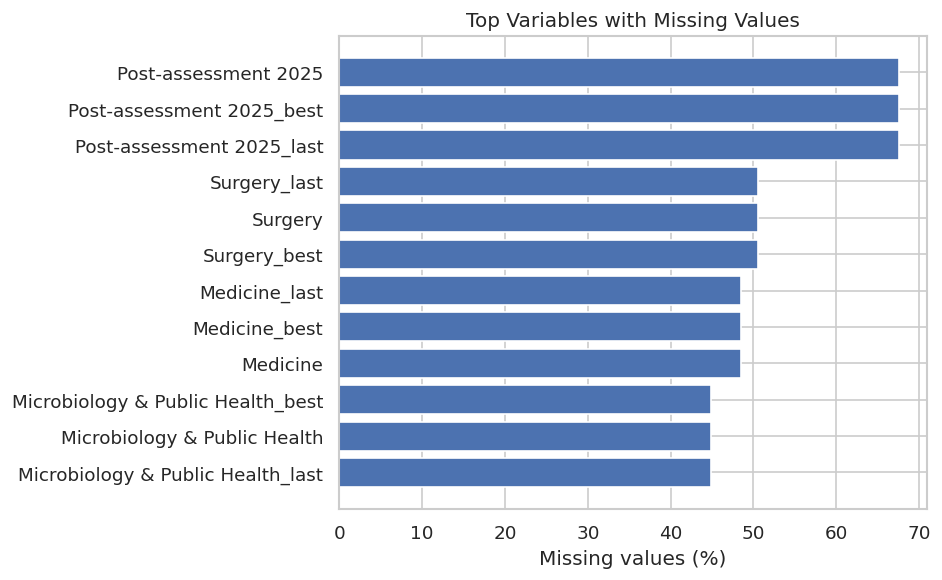

In [ ]:
# 3a.2 Missing values

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0].head(15))

# Visualization: top missing variables
top_missing = missing_summary[missing_summary["missing_count"] > 0].head(12).sort_values("missing_percent")
plt.figure(figsize=(8, 5))
plt.barh(top_missing.index, top_missing["missing_percent"])
plt.xlabel("Missing values (%)")
plt.title("Top Variables with Missing Values")
plt.tight_layout()
plt.show()

In [ ]:
# 3a.3 Outlier inspection using IQR

outlier_records = []

for col in numeric_feature_cols:
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((series < lower) | (series > upper)).sum()

    outlier_records.append({
        "variable": col,
        "outlier_count": outlier_count,
        "lower_bound": lower,
        "upper_bound": upper
    })

outlier_summary = pd.DataFrame(outlier_records).sort_values("outlier_count", ascending=False)
display(outlier_summary.head(10))


,variable,outlier_count,lower_bound,upper_bound
39,avg_improvement,39,-13.162500,21.937500
8,Medicine,26,47.000000,95.000000
19,Medicine_last,19,43.500000,103.500000
30,Medicine_best,17,40.500000,108.500000
0,Pre-assessment 2025,17,19.250000,73.250000
38,avg_attempts,16,-0.167045,3.126894
18,Microbiology & Public Health_last,15,31.000000,111.000000
20,Surgery_last,15,38.000000,102.000000
37,total_attempts,15,-12.500000,31.500000
9,Surgery,13,37.500000,97.500000


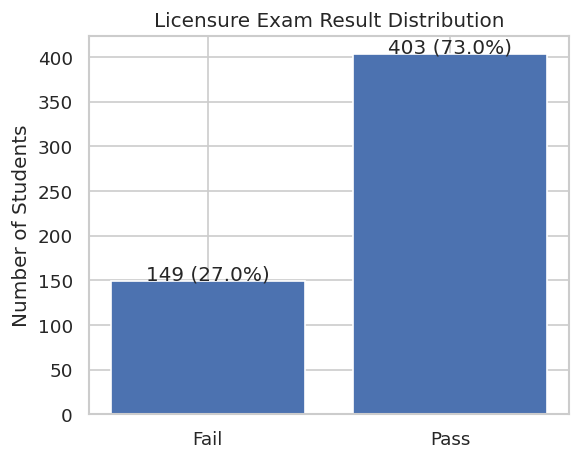

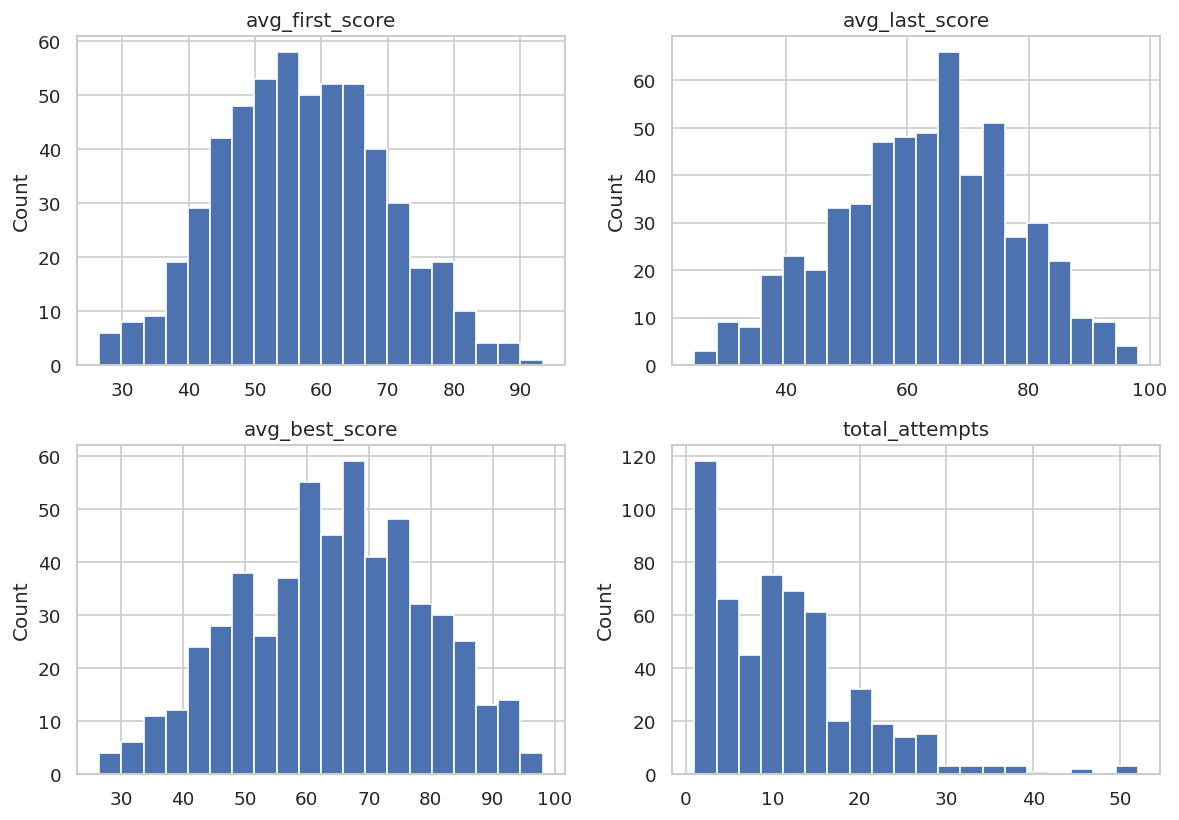

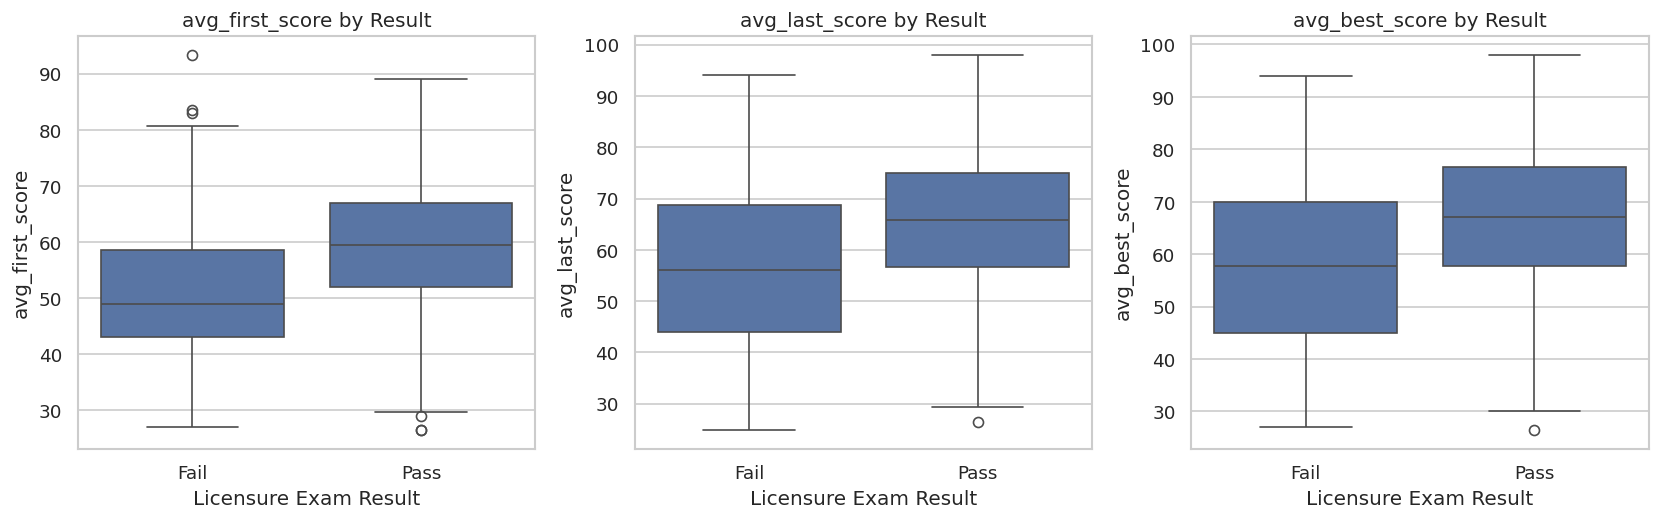

,avg_first_score,avg_last_score,avg_best_score,total_attempts,num_exams
Fail,51.90,56.67,57.97,8.81,5.25
Pass,59.22,65.32,66.77,12.38,7.48


Pass rates by Gender


Licensure Exam Result,0,1
Gender,,
Female,0.269634,0.730366
Male,0.257862,0.742138


Pass rates by Type of Examinee


Licensure Exam Result,0,1
Type of Examinee,,
First Taker,0.190476,0.809524
Repeater,0.373913,0.626087


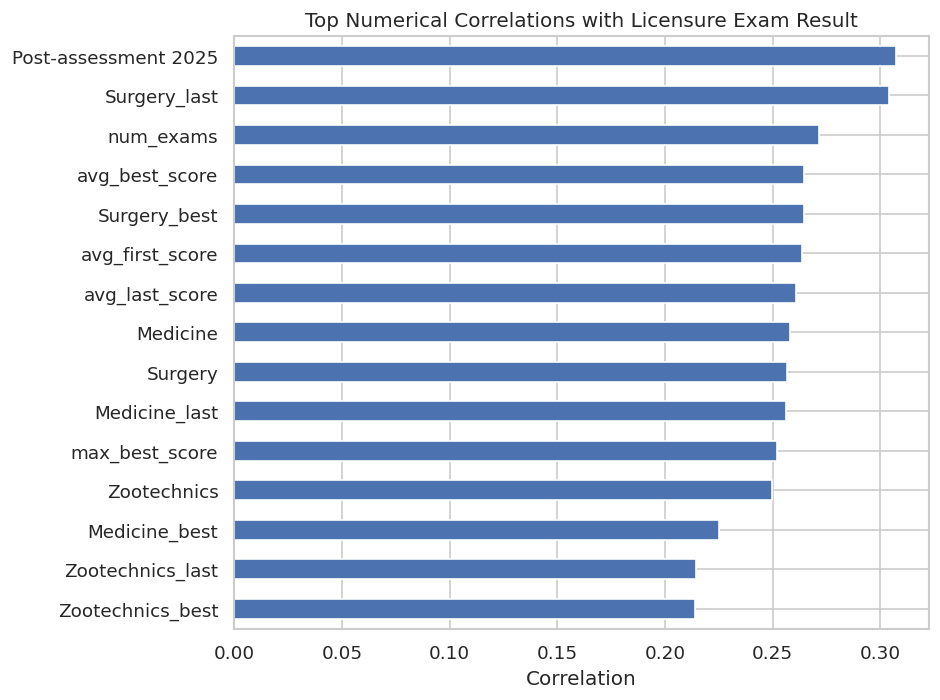

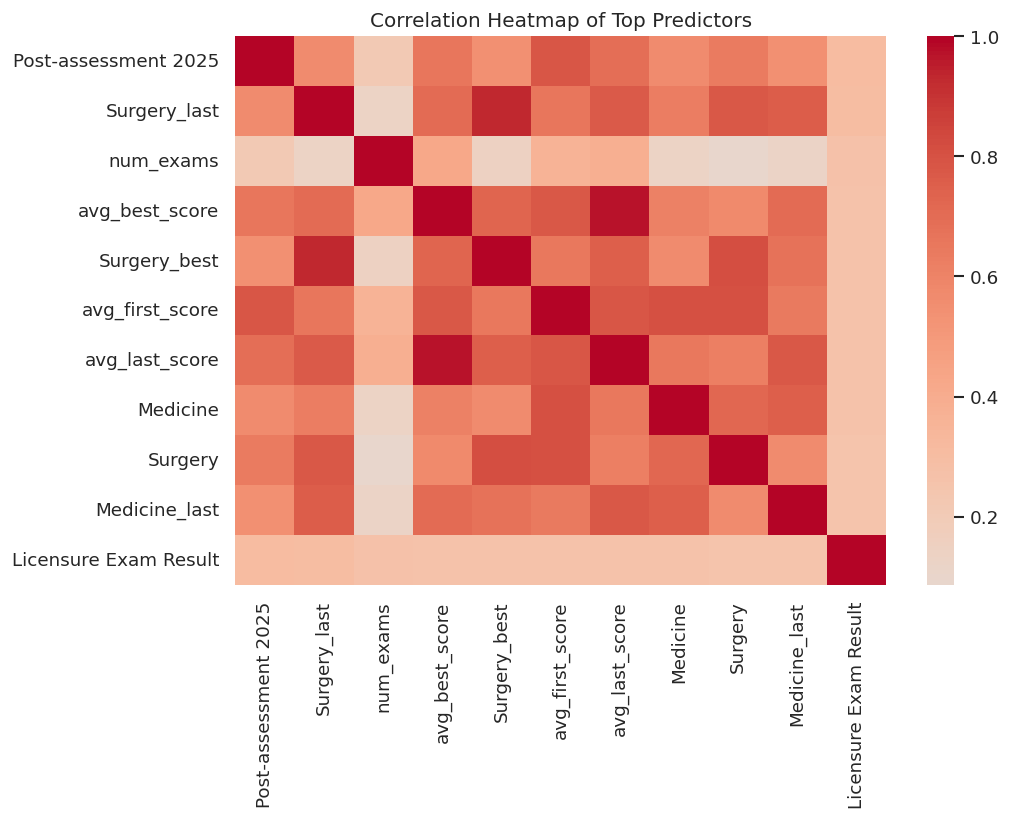

,Licensure Exam Result
Post-assessment 2025,0.307098
Surgery_last,0.303776
num_exams,0.271575
avg_best_score,0.264638
Surgery_best,0.264430
avg_first_score,0.263496
avg_last_score,0.260960
Medicine,0.258145
Surgery,0.256535
Medicine_last,0.256129


In [ ]:
# 3b. Exploratory Data Analysis (EDA)


# 3b.1 Target distribution

target_counts = df[target_col].value_counts().sort_index()
target_labels = ["Fail", "Pass"]

plt.figure(figsize=(5, 4))
bars = plt.bar(target_labels, [target_counts.get(0, 0), target_counts.get(1, 0)])
plt.title("Licensure Exam Result Distribution")
plt.ylabel("Number of Students")

total_n = len(df)
for bar, value in zip(bars, [target_counts.get(0, 0), target_counts.get(1, 0)]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value} ({value / total_n:.1%})",
        ha="center"
    )
plt.tight_layout()
plt.show()


# 3b.2 Univariate analysis

aggregate_cols = ["avg_first_score", "avg_last_score", "avg_best_score", "total_attempts"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flatten(), aggregate_cols):
    ax.hist(df[col].dropna(), bins=20)
    ax.set_title(col)
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


# 3b.3 Bivariate analysis: pass vs fail

boxplot_cols = ["avg_first_score", "avg_last_score", "avg_best_score"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col in zip(axes, boxplot_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_xticklabels(["Fail", "Pass"])
    ax.set_title(f"{col} by Result")
plt.tight_layout()
plt.show()

# Group means for interpretation
group_means = df.groupby(target_col)[["avg_first_score", "avg_last_score", "avg_best_score", "total_attempts", "num_exams"]].mean().round(2)
group_means.index = ["Fail", "Pass"]
display(group_means)


# 3b.4 Relationships for categorical variables

gender_passrate = pd.crosstab(df["Gender"], df[target_col], normalize="index")
examinee_passrate = pd.crosstab(df["Type of Examinee"], df[target_col], normalize="index")

print("Pass rates by Gender")
display(gender_passrate)

print("Pass rates by Type of Examinee")
display(examinee_passrate)


# 3b.5 Correlation analysis

correlations = df[numeric_feature_cols + [target_col]].corr(numeric_only=True)[target_col].drop(target_col)
top_correlations = correlations.reindex(correlations.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(8, 6))
top_correlations.sort_values().plot(kind="barh")
plt.title("Top Numerical Correlations with Licensure Exam Result")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

# Heatmap for the strongest variables
heatmap_cols = top_correlations.index.tolist()[:10] + [target_col]
plt.figure(figsize=(9, 7))
sns.heatmap(df[heatmap_cols].corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Top Predictors")
plt.tight_layout()
plt.show()

display(top_correlations)


In [ ]:
# 3c. Feature Engineering

# Create a copy so raw data stays intact
df_fe = df.copy()

# Domain-informed engineered features
# These aim to capture engagement, learning gain, and score stability
df_fe["exam_coverage_ratio"] = df_fe["num_exams"] / 11
df_fe["best_minus_first"] = df_fe["avg_best_score"] - df_fe["avg_first_score"]
df_fe["last_minus_first"] = df_fe["avg_last_score"] - df_fe["avg_first_score"]
df_fe["best_minus_last"] = df_fe["avg_best_score"] - df_fe["avg_last_score"]
df_fe["attempt_intensity"] = df_fe["total_attempts"] / df_fe["num_exams"].replace(0, np.nan)
df_fe["stability_index"] = 1 / (1 + df_fe["score_std"])
df_fe["score_range_proxy"] = df_fe["max_best_score"] - df_fe["avg_first_score"]

engineered_cols = [
    "exam_coverage_ratio",
    "best_minus_first",
    "last_minus_first",
    "best_minus_last",
    "attempt_intensity",
    "stability_index",
    "score_range_proxy",
]

display(df_fe[engineered_cols].head())

# Quick check of engineered feature behavior by target
engineered_group_means = df_fe.groupby(target_col)[engineered_cols].mean().round(3)
engineered_group_means.index = ["Fail", "Pass"]
display(engineered_group_means)



,exam_coverage_ratio,best_minus_first,last_minus_first,best_minus_last,attempt_intensity,stability_index,score_range_proxy
0,0.454545,0.0,-1.8,1.8,1.2,0.104331,10.200000
1,0.545455,0.0,0.0,0.0,1.0,0.120307,8.333333
2,0.181818,0.0,0.0,0.0,1.0,0.414214,1.000000
3,0.909091,20.5,19.1,1.4,2.9,0.051703,37.300000
4,0.909091,3.9,3.9,0.0,1.2,0.113965,11.900000


,exam_coverage_ratio,best_minus_first,last_minus_first,best_minus_last,attempt_intensity,stability_index,score_range_proxy
Fail,0.477,6.070,4.772,1.297,1.497,0.282,19.690
Pass,0.680,7.548,6.103,1.445,1.604,0.146,22.915


Top 10 Chi-square features


,0
num__stability_index,13.442272
cat__Type of Examinee_Repeater,12.620028
num__num_exams,9.227420
num__exam_coverage_ratio,9.227420
cat__Type of Examinee_First Taker,9.014305
num__max_best_score,3.169399
num__avg_best_score,3.108481
num__avg_last_score,2.925487
num__avg_first_score,2.837345
num__total_attempts,2.619595


RFE selected features:
- num__Pharmacology
- num__Post-assessment 2025
- num__Medicine_last
- num__Medicine_best
- num__Post-assessment 2025_best
- num__avg_best_score
- num__score_std
- num__exam_coverage_ratio
- num__stability_index
- cat__Type of Examinee_Repeater
Top 10 Random Forest feature importances


,0
num__avg_first_score,0.063916
num__avg_last_score,0.041254
num__avg_best_score,0.038360
num__score_range_proxy,0.031562
num__max_best_score,0.031470
num__stability_index,0.030236
num__score_std,0.029167
num__Anatomy_last,0.027764
num__Anatomy,0.027708
num__Pre-assessment 2025,0.027374


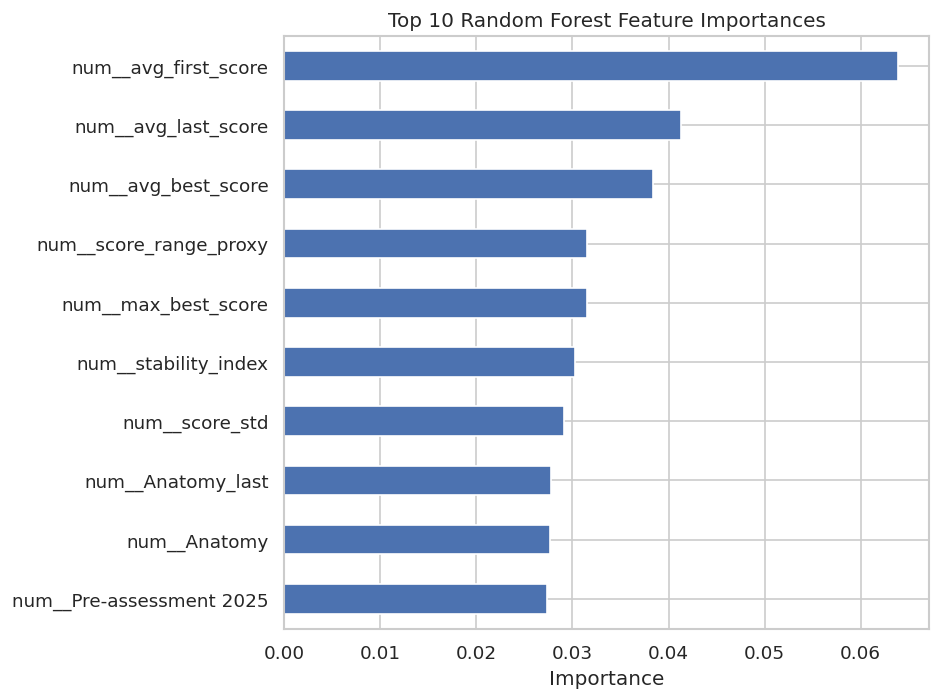

In [ ]:
# 3d. Feature Selection

# Exclude ID and target from X
X = df_fe.drop(columns=[id_col, target_col])
y = df_fe[target_col]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()


# 3d.1 Filter method: Chi-square

# Chi-square requires non-negative values, so I use MinMaxScaler.
chi_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", MinMaxScaler())
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_features)
    ]
)

X_chi = chi_preprocessor.fit_transform(X)
chi_feature_names = chi_preprocessor.get_feature_names_out()

chi_selector = SelectKBest(score_func=chi2, k=10)
chi_selector.fit(X_chi, y)

chi_scores = pd.Series(chi_selector.scores_, index=chi_feature_names).sort_values(ascending=False)
print("Top 10 Chi-square features")
display(chi_scores.head(10))


# 3d.2 Wrapper method: RFE

rfe_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
        ]), cat_features)
    ]
)

X_model = rfe_preprocessor.fit_transform(X)
model_feature_names = rfe_preprocessor.get_feature_names_out()

rfe_model = LogisticRegression(max_iter=3000, solver="liblinear")
rfe_selector = RFE(estimator=rfe_model, n_features_to_select=10)
rfe_selector.fit(X_model, y)

rfe_selected_features = pd.Series(rfe_selector.support_, index=model_feature_names)
rfe_selected_features = rfe_selected_features[rfe_selected_features].index.tolist()

print("RFE selected features:")
for feature in rfe_selected_features:
    print("-", feature)


# 3d.3 Embedded method: Tree-based importance

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_model, y)

rf_importances = pd.Series(rf_model.feature_importances_, index=model_feature_names).sort_values(ascending=False)
print("Top 10 Random Forest feature importances")
display(rf_importances.head(10))

plt.figure(figsize=(8, 6))
rf_importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



Components for 80% variance: 10
Components for 90% variance: 16
Components for 95% variance: 22


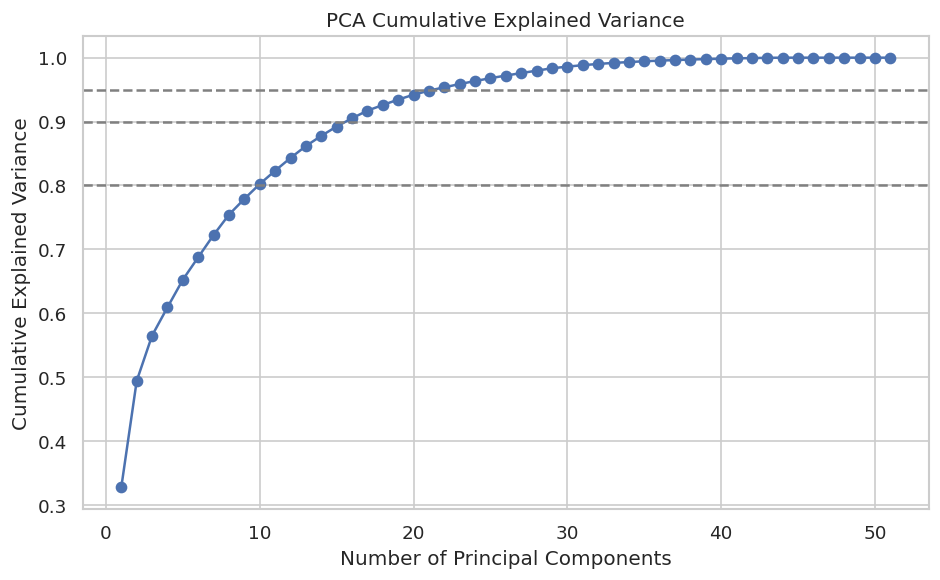

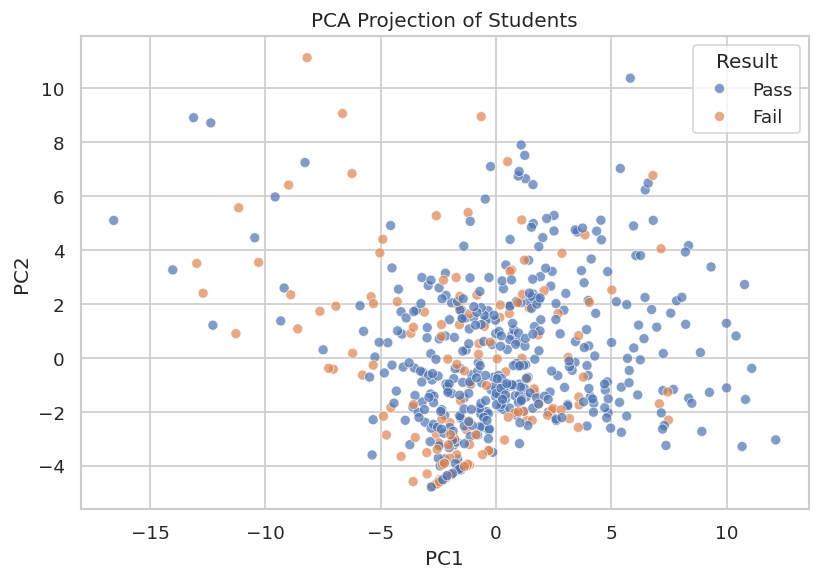

In [ ]:
# 3e. Dimensionality Reduction (PCA)


# PCA should be done on imputed + encoded + scaled data
X_pca_input = X_model.toarray() if hasattr(X_model, "toarray") else X_model

pca = PCA()
pca.fit(X_pca_input)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# How many components for common thresholds?
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components for 80% variance:", n_components_80)
print("Components for 90% variance:", n_components_90)
print("Components for 95% variance:", n_components_95)

# Scree / cumulative variance plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(0.80, linestyle="--", color="gray")
plt.axhline(0.90, linestyle="--", color="gray")
plt.axhline(0.95, linestyle="--", color="gray")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.tight_layout()
plt.show()

# 2D PCA visualization
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_pca_input)

pca_df = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "Result": y.map({0: "Fail", 1: "Pass"})
})

plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Result", alpha=0.7)
plt.title("PCA Projection of Students")
plt.tight_layout()
plt.show()



In [ ]:
# 4. Final Step 3 Output Summary

print("\nSTEP 3 SUMMARY")
print("1. Data cleaning documented missing values, duplicates, and IQR-based outliers.")
print("2. EDA showed that passers tend to have higher aggregate scores and broader exam coverage.")
print("3. Feature engineering added engagement, gain, and stability variables.")
print("4. Feature selection used filter, wrapper, and embedded methods.")
print("5. PCA was applied and justified as an optional dimensionality reduction branch.")




STEP 3 SUMMARY
1. Data cleaning documented missing values, duplicates, and IQR-based outliers.
2. EDA showed that passers tend to have higher aggregate scores and broader exam coverage.
3. Feature engineering added engagement, gain, and stability variables.
4. Feature selection used filter, wrapper, and embedded methods.
5. PCA was applied and justified as an optional dimensionality reduction branch.


In [ ]:
# Saved engineered dataset for Step 4
df_fe.to_csv("step3_engineered_dataset.csv", index=False)
print("\nSaved engineered dataset as: step3_engineered_dataset.csv")


Saved engineered dataset as: step3_engineered_dataset.csv
